<a href="https://colab.research.google.com/github/ababilkhoerulimam/text-processing-week4/blob/main/ababil%20bethania_exercise%204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3 - Web Scraping (HTTP Request & API)

**Chapter 3 - Web Scraping**

Target website: https://news.ycombinator.com/

Anggota Kelompok (2 mahasiswa):
1. Ababil Khoerul Imam - 152
2. Bethania Putri Junjungsari Nugraha - 115

**Tugas:** Melakukan scraping terhadap sebuah website menggunakan dua pendekatan, yaitu:
1. **HTTP Request** langsung ke halaman web (`requests` + `BeautifulSoup`)
2. **API** (Application Programming Interface) yang menyediakan data terkait website tersebut

## 0. Persiapan (Import Library)

Library yang digunakan mengikuti materi Chapter 3:
- `requests` untuk mengambil dokumen HTML/JSON dari internet
- `BeautifulSoup` untuk mem-parsing (membaca struktur) dokumen HTML
- `pandas` untuk menyimpan hasil scraping ke dalam bentuk tabel (DataFrame)
- `matplotlib.pyplot` untuk memvisualisasikan data hasil scraping

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

## 1. Web Scraping dengan HTTP Request

Pada bagian ini kita melakukan request langsung ke halaman utama Hacker News (`https://news.ycombinator.com/`) menggunakan library `requests`, kemudian mem-parsing struktur HTML menggunakan `BeautifulSoup` untuk mengekstrak daftar thread artikel, tautan URL, skor poin, dan pembuat postingan.

In [ ]:
# 1.1 Request halaman utama Hacker News
url = 'https://news.ycombinator.com/'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                  '(KHTML, like Gecko) Chrome/124.0 Safari/537.36'
}

page = requests.get(url, headers=headers)
page

<Response [200]>

In [ ]:
# 1.2 Lihat isi HTML mentah (potongan awal)
print(page.text[:1500])

<html lang="en" op="news"><head><meta name="referrer" content="origin"><meta name="viewport" content="width=device-width, initial-scale=1.0"><link rel="icon" href="y18.svg"><link rel="stylesheet" type="text/css" href="news.css?p9DVimPa4KE9hyScgN6l"><link rel="alternate" type="application/rss+xml" title="RSS" href="rss"><title>Hacker News</title></head><body><center><table id="hnmain" border="0" cellpadding="0" cellspacing="0" width="85%" bgcolor="#f6f6ef"><tr><td bgcolor="#ff6600"><table border="0" cellpadding="0" cellspacing="0" width="100%" style="padding:2px"><tr><td style="width:18px;padding-right:4px"><a href="https://news.ycombinator.com"><img src="y18.svg" width="18" height="18" style="border:1px white solid; display:block"></a></td><td style="line-height:12pt; height:10px;"><span class="pagetop"><b class="hnname"><a href="news">Hacker News</a></b><a href="newest">new</a> | <a href="front">past</a> | <a href="newcomments">comments</a> | <a href="ask">ask</a> | <a href="show">sho

In [ ]:
# 1.3 Parsing HTML menggunakan BeautifulSoup
bs = BeautifulSoup(page.text, 'html.parser')
bs.title

<title>Hacker News</title>

In [ ]:
# 1.4 Ambil informasi dasar halaman
judul = bs.find('title').text
total_baris_artikel = len(bs.find_all('tr', class_='athing'))

print('Judul Halaman:', judul)
print('Total Baris Artikel (athing):', total_baris_artikel)

Judul Halaman: Hacker News
Total Baris Artikel (athing): 30


In [ ]:
# 1.5 Ekstraksi daftar artikel dari baris tabel .athing
rows = bs.find_all('tr', class_='athing')

daftar_artikel = []
for r in rows:
    story_id = r.get('id')
    title_span = r.find('span', class_='titleline')
    title_a = title_span.find('a') if title_span else None
    if title_a:
        daftar_artikel.append({
            'id': story_id,
            'title': title_a.text.strip(),
            'url': title_a.get('href')
        })

df_http = pd.DataFrame(daftar_artikel)
print('Jumlah artikel ditemukan:', len(df_http))
df_http.head(10)

Jumlah artikel ditemukan: 30


,id,title,url
0,49890051,Using any C++ library in Godot,https://blog.conan.io/cpp/conan/gamedev/godot/...
1,49890226,AI companies leak data to advertisers [pdf],https://jorgegarciaherrero.com/wp-content/inte...
2,49880411,Phyllotaxis: An audio-reactive LED display,https://jagi.studio/posts/phyllotaxis/
3,49876052,The systems that no one will test,https://blog.christianperone.com/2026/09/the-s...
4,49870376,"Booted up in 1993, this server still runs – bu...",https://www.computerworld.com/article/1673071/...
5,49880036,Pirating the Pirates,https://mubi.com/en/notebook/posts/pirating-th...
6,49866783,Software occlusion culling in Block Game,https://enikofox.com/posts/software-rendered-o...
7,49883539,California farmers are struggling to sell grap...,https://www.kqed.org/news/12101534/california-...
8,49886482,Tank Body Problem,http://www.jimsitu.com
9,49885493,Show HN: Pac-Bench – How well can models one-s...,https://jonclegg.github.io/pacman-bakeoff/


In [ ]:
# 1.6 Ekstraksi metadata pendukung (poin dan author) dari baris .subtext
subtext_rows = bs.find_all('td', class_='subtext')

poin_list = []
author_list = []
for sub in subtext_rows:
    score_elem = sub.find('span', class_='score')
    author_elem = sub.find('a', class_='hnuser')
    poin = score_elem.text.replace(' points', '').replace(' point', '').strip() if score_elem else '0'
    author = author_elem.text.strip() if author_elem else 'anonymous'
    poin_list.append(int(poin) if poin.isdigit() else 0)
    author_list.append(author)

if len(poin_list) == len(df_http):
    df_http['score'] = poin_list
    df_http['author'] = author_list

df_http[['id', 'title', 'score', 'author']].head(10)

,id,title,score,author
0,49890051,Using any C++ library in Godot,35,czoido
1,49890226,AI companies leak data to advertisers [pdf],33,damaru2
2,49880411,Phyllotaxis: An audio-reactive LED display,148,evakhoury
3,49876052,The systems that no one will test,66,perone
4,49870376,"Booted up in 1993, this server still runs – bu...",53,doener
5,49880036,Pirating the Pirates,594,piotrgrabowski
6,49866783,Software occlusion culling in Block Game,16,airhangerf15
7,49883539,California farmers are struggling to sell grap...,227,randycupertino
8,49886482,Tank Body Problem,116,jimbooonooo
9,49885493,Show HN: Pac-Bench – How well can models one-s...,62,thefourthchime


**Catatan karakteristik website:**

`news.ycombinator.com` menggunakan arsitektur server-side rendering murni dengan markup HTML berbasis tabel (`<table>`, `<tr>`, `<td>`). Struktur statis ini memungkinkan library `requests` dan `BeautifulSoup` mengekstrak seluruh konten utama secara lengkap tanpa memerlukan browser automation engine (seperti Selenium atau Playwright).

## 2. Web Scraping dengan API

Hacker News menyediakan Official REST API gratis yang di-host di Google Firebase (`https://hacker-news.firebaseio.com/v0/`). API ini bersifat open access (tanpa perlu API key) dan mengembalikan data dalam format JSON terstruktur untuk berbagai entitas, termasuk `topstories`, `newstories`, dan detail `item` berdasarkan ID.

Dokumentasi resmi: https://github.com/HackerNews/API

In [ ]:
# 2.1 Ambil daftar ID untuk kategori top stories
url_top = 'https://hacker-news.firebaseio.com/v0/topstories.json'
response_top = requests.get(url_top)

print('Status code:', response_top.status_code)
if response_top.status_code == 200:
    top_ids = response_top.json()
    print('Jumlah ID top stories tersedia:', len(top_ids))
    print('Contoh 10 ID pertama:', top_ids[:10])

Status code: 200
Jumlah ID top stories tersedia: 500
Contoh 10 ID pertama: [49890051, 49890226, 49880411, 49876052, 49870376, 49880036, 49866783, 49883539, 49886482, 49882781]


In [ ]:
# 2.2 Prototipe pengambilan detail 1 story berdasarkan ID
sample_id = top_ids[0]
url_item = f'https://hacker-news.firebaseio.com/v0/item/{sample_id}.json'
sample_item = requests.get(url_item).json()

print('ID         :', sample_item.get('id'))
print('Judul      :', sample_item.get('title'))
print('Author     :', sample_item.get('by'))
print('Skor (Up)  :', sample_item.get('score'))
print('Komentar   :', sample_item.get('descendants'))
print('URL        :', sample_item.get('url'))

ID         : 49890051
Judul      : Using any C++ library in Godot
Author     : czoido
Skor (Up)  : 35
Komentar   : 10
URL        : https://blog.conan.io/cpp/conan/gamedev/godot/cmake/2026/09/29/Using-Any-Cpp-Library-In-Godot.html


In [ ]:
# 2.3 Ambil detail 30 top stories secara batch
stories_data = []

for sid in top_ids[:30]:
    item_url = f'https://hacker-news.firebaseio.com/v0/item/{sid}.json'
    res = requests.get(item_url)
    if res.status_code == 200:
        data = res.json()
        if data:
            stories_data.append({
                'id': data.get('id'),
                'title': data.get('title'),
                'by': data.get('by'),
                'score': data.get('score', 0),
                'comments': data.get('descendants', 0),
                'time': data.get('time'),
                'url': data.get('url')
            })

print('Total stories berhasil diunduh via API:', len(stories_data))

Total stories berhasil diunduh via API: 30


In [ ]:
# 2.4 Susun hasil scraping API ke dalam pandas DataFrame
df_api = pd.DataFrame(stories_data)

# Konversi unix timestamp ke datetime UTC
df_api['datetime_utc'] = pd.to_datetime(df_api['time'], unit='s')

print('Dimensi data:', df_api.shape)
df_api[['id', 'title', 'by', 'score', 'comments', 'datetime_utc']].head(10)

Dimensi data: (30, 8)


,id,title,by,score,comments,datetime_utc
0,49890051,Using any C++ library in Godot,czoido,35,10,2026-09-29 08:40:37
1,49890226,AI companies leak data to advertisers [pdf],damaru2,35,5,2026-09-29 09:03:41
2,49880411,Phyllotaxis: An audio-reactive LED display,evakhoury,148,16,2026-09-28 16:18:57
3,49876052,The systems that no one will test,perone,67,26,2026-09-28 10:51:46
4,49870376,"Booted up in 1993, this server still runs – bu...",doener,53,14,2026-09-27 20:13:22
5,49880036,Pirating the Pirates,piotrgrabowski,594,290,2026-09-28 15:54:15
6,49866783,Software occlusion culling in Block Game,airhangerf15,17,0,2026-09-27 14:07:41
7,49883539,California farmers are struggling to sell grap...,randycupertino,227,540,2026-09-28 20:00:06
8,49886482,Tank Body Problem,jimbooonooo,116,25,2026-09-29 00:41:45
9,49882781,MicroLLM Lab – Try 7 tiny LLM's in the browser,logicallee,246,86,2026-09-28 18:58:53


In [ ]:
# 2.5 Simpan hasil scraping API ke file CSV
csv_filename = 'hackernews_stories.csv'
df_api.to_csv(csv_filename, index=False)
print(f'File berhasil disimpan: {csv_filename} dengan dimensi {df_api.shape}')

File berhasil disimpan: hackernews_stories.csv dengan dimensi (30, 8)


### 2.6 Analisis Singkat & Visualisasi Data Scraping API

Sebagai pemanfaatan data hasil scraping API, kita melakukan eksplorasi sederhana:
1. Top 10 stories dengan skor upvotes tertinggi
2. Distribusi statistik skor dan jumlah komentar
3. Frekuensi kontributor (penulis postingan) teraktif

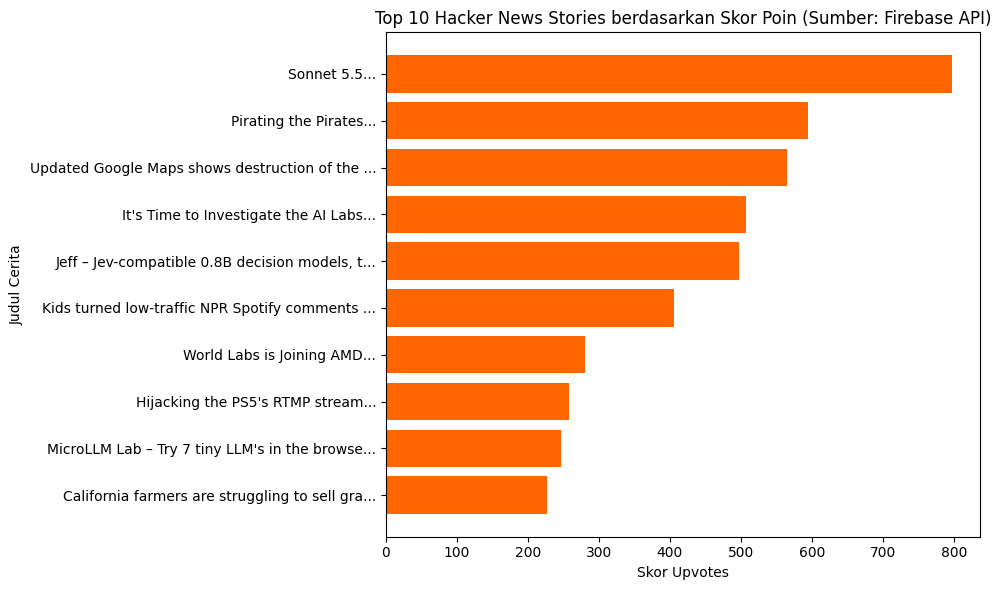

In [ ]:
# Visualisasi 10 Stories dengan Skor Poin Tertinggi
top10_stories = df_api.sort_values(by='score', ascending=True).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_stories['title'].str[:45] + '...', top10_stories['score'], color='#ff6600')
plt.title('Top 10 Hacker News Stories berdasarkan Skor Poin (Sumber: Firebase API)')
plt.xlabel('Skor Upvotes')
plt.ylabel('Judul Cerita')
plt.tight_layout()
plt.show()

In [ ]:
# Ringkasan statistik deskriptif untuk skor dan jumlah komentar
df_api[['score', 'comments']].describe()

,score,comments
count,30.000000,30.000000
mean,203.900000,119.900000
std,204.553399,154.208401
min,4.000000,0.000000
25%,55.250000,14.500000
50%,127.000000,43.500000
75%,255.000000,202.000000
max,797.000000,540.000000


In [ ]:
# Frekuensi pembuat postingan (author)
df_api['by'].value_counts().head(10)

,count
by,
ibobev,2
soltanov,2
czoido,1
damaru2,1
doener,1
piotrgrabowski,1
airhangerf15,1
randycupertino,1
jimbooonooo,1


## 3. Kesimpulan

* **HTTP Request** menggunakan `requests` dan `BeautifulSoup` berhasil mengekstrak 30 artikel pada halaman utama `news.ycombinator.com`. Karena website ini menggunakan server-side rendering berbasis tabel HTML standar (`.athing` dan `.subtext`), seluruh judul artikel, tautan, dan poin dapat diparsing secara lengkap tanpa kehilangan data elemen.

* **API** menggunakan official Firebase REST API (`hacker-news.firebaseio.com`) memberikan pendekatan yang jauh lebih stabil, presisi, dan terstruktur. Nilai numerik seperti ID story, skor upvotes aktual, total komentar (`descendants`), dan timestamp UNIX dapat diakses langsung dalam format JSON tanpa risiko kerapuhan selector CSS HTML.

* Dataset yang dihasilkan, `hackernews_stories.csv`, berisi 30 baris data riil dengan kolom `title` yang kaya akan teks natural berbahasa Inggris. Dataset ini siap dan valid untuk digunakan pada tahap berikutnya, yaitu **Exercise 4 (Text Pre-processing)**, untuk proses case folding, tokenizing, stopword removal, dan stemming.

# Exercise 4

## Text Pre-processing

Try to preprocess the text you scrape from the Exercise 3.

Pada exercise ini, text yang digunakan adalah **title** dari data Hacker News yang sudah diperoleh pada Exercise 3 (`df_api`).

### 1. Menampilkan Text Hasil Scraping dari Exercise 3

In [ ]:
df_api[['id', 'title']].head(10)

,id,title
0,49890051,Using any C++ library in Godot
1,49890226,AI companies leak data to advertisers [pdf]
2,49880411,Phyllotaxis: An audio-reactive LED display
3,49876052,The systems that no one will test
4,49870376,"Booted up in 1993, this server still runs – bu..."
5,49880036,Pirating the Pirates
6,49866783,Software occlusion culling in Block Game
7,49883539,California farmers are struggling to sell grap...
8,49886482,Tank Body Problem
9,49882781,MicroLLM Lab – Try 7 tiny LLM's in the browser


### 2. Remove HTML

In [ ]:
import re

def remove_html(text):
    html_pattern = re.compile('<.*?>')
    return html_pattern.sub(r'', text)

df_api['rm_html'] = df_api['title'].apply(remove_html)

df_api[['title', 'rm_html']].head(10)

,title,rm_html
0,Using any C++ library in Godot,Using any C++ library in Godot
1,AI companies leak data to advertisers [pdf],AI companies leak data to advertisers [pdf]
2,Phyllotaxis: An audio-reactive LED display,Phyllotaxis: An audio-reactive LED display
3,The systems that no one will test,The systems that no one will test
4,"Booted up in 1993, this server still runs – bu...","Booted up in 1993, this server still runs – bu..."
5,Pirating the Pirates,Pirating the Pirates
6,Software occlusion culling in Block Game,Software occlusion culling in Block Game
7,California farmers are struggling to sell grap...,California farmers are struggling to sell grap...
8,Tank Body Problem,Tank Body Problem
9,MicroLLM Lab – Try 7 tiny LLM's in the browser,MicroLLM Lab – Try 7 tiny LLM's in the browser


### 3. Remove Hashtag

In [ ]:
def remove_hashtag(text):
    return re.sub(r'#\w+', '', text)

df_api['rm_hashtag'] = df_api['rm_html'].apply(remove_hashtag)

df_api[['rm_html', 'rm_hashtag']].head(10)

,rm_html,rm_hashtag
0,Using any C++ library in Godot,Using any C++ library in Godot
1,AI companies leak data to advertisers [pdf],AI companies leak data to advertisers [pdf]
2,Phyllotaxis: An audio-reactive LED display,Phyllotaxis: An audio-reactive LED display
3,The systems that no one will test,The systems that no one will test
4,"Booted up in 1993, this server still runs – bu...","Booted up in 1993, this server still runs – bu..."
5,Pirating the Pirates,Pirating the Pirates
6,Software occlusion culling in Block Game,Software occlusion culling in Block Game
7,California farmers are struggling to sell grap...,California farmers are struggling to sell grap...
8,Tank Body Problem,Tank Body Problem
9,MicroLLM Lab – Try 7 tiny LLM's in the browser,MicroLLM Lab – Try 7 tiny LLM's in the browser


### 4. Lower Casing

In [ ]:
df_api['lower_case'] = df_api['rm_hashtag'].str.lower()

df_api[['rm_hashtag', 'lower_case']].head(10)

,rm_hashtag,lower_case
0,Using any C++ library in Godot,using any c++ library in godot
1,AI companies leak data to advertisers [pdf],ai companies leak data to advertisers [pdf]
2,Phyllotaxis: An audio-reactive LED display,phyllotaxis: an audio-reactive led display
3,The systems that no one will test,the systems that no one will test
4,"Booted up in 1993, this server still runs – bu...","booted up in 1993, this server still runs – bu..."
5,Pirating the Pirates,pirating the pirates
6,Software occlusion culling in Block Game,software occlusion culling in block game
7,California farmers are struggling to sell grap...,california farmers are struggling to sell grap...
8,Tank Body Problem,tank body problem
9,MicroLLM Lab – Try 7 tiny LLM's in the browser,microllm lab – try 7 tiny llm's in the browser


### 5. Remove URL and Email

In [ ]:
def remove_rls(text):
    text = re.sub(r'https?\/\/S+', '', str(text))
    text = re.sub(r'http\S+', '', str(text))
    text = re.sub(r'www\S+', '', str(text))
    text = re.sub(r'\S+@\S+', '', str(text))
    return text

df_api['rm_url'] = df_api['lower_case'].apply(remove_rls)

df_api[['lower_case', 'rm_url']].head(10)

,lower_case,rm_url
0,using any c++ library in godot,using any c++ library in godot
1,ai companies leak data to advertisers [pdf],ai companies leak data to advertisers [pdf]
2,phyllotaxis: an audio-reactive led display,phyllotaxis: an audio-reactive led display
3,the systems that no one will test,the systems that no one will test
4,"booted up in 1993, this server still runs – bu...","booted up in 1993, this server still runs – bu..."
5,pirating the pirates,pirating the pirates
6,software occlusion culling in block game,software occlusion culling in block game
7,california farmers are struggling to sell grap...,california farmers are struggling to sell grap...
8,tank body problem,tank body problem
9,microllm lab – try 7 tiny llm's in the browser,microllm lab – try 7 tiny llm's in the browser


### 6. Remove Punctuation

In [ ]:
def remove_punctuation_list(text):
    text = re.sub(r'(:\)|:-\)|:D|:-D|;\)|;-\))', '', text)
    text = re.sub(r'(:\(|:-\()', '', text)
    text = re.sub(r'(:v|:-v)', '', text)

    text = re.sub(r'[!"#$%&\'()*+,\-./:;<=>?@\[\]^_`{|}~]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_api['rm_punc'] = df_api['rm_url'].apply(remove_punctuation_list)

df_api[['rm_url', 'rm_punc']].head(10)

,rm_url,rm_punc
0,using any c++ library in godot,using any c library in godot
1,ai companies leak data to advertisers [pdf],ai companies leak data to advertisers pdf
2,phyllotaxis: an audio-reactive led display,phyllotaxis an audio reactive led display
3,the systems that no one will test,the systems that no one will test
4,"booted up in 1993, this server still runs – bu...",booted up in 1993 this server still runs – but...
5,pirating the pirates,pirating the pirates
6,software occlusion culling in block game,software occlusion culling in block game
7,california farmers are struggling to sell grap...,california farmers are struggling to sell grap...
8,tank body problem,tank body problem
9,microllm lab – try 7 tiny llm's in the browser,microllm lab – try 7 tiny llm s in the browser


### 7. Remove Emoji

In [ ]:
!pip install demoji

import demoji

def remove_emoji(text):
    cleaned_text = demoji.replace(text, repl="")
    return cleaned_text

df_api['rm_emoji'] = df_api['rm_punc'].apply(remove_emoji)

df_api[['rm_punc', 'rm_emoji']].head(10)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 1.4 MB/s eta 0:00:00


,rm_punc,rm_emoji
0,using any c library in godot,using any c library in godot
1,ai companies leak data to advertisers pdf,ai companies leak data to advertisers pdf
2,phyllotaxis an audio reactive led display,phyllotaxis an audio reactive led display
3,the systems that no one will test,the systems that no one will test
4,booted up in 1993 this server still runs – but...,booted up in 1993 this server still runs – but...
5,pirating the pirates,pirating the pirates
6,software occlusion culling in block game,software occlusion culling in block game
7,california farmers are struggling to sell grap...,california farmers are struggling to sell grap...
8,tank body problem,tank body problem
9,microllm lab – try 7 tiny llm s in the browser,microllm lab – try 7 tiny llm s in the browser


### 8. Tokenizing

In [ ]:
import nltk

nltk.download('punkt_tab')

def tokenize_text(text):
    return nltk.word_tokenize(text)

df_api['tokens'] = df_api['rm_emoji'].apply(tokenize_text)

df_api[['rm_emoji', 'tokens']].head(10)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,rm_emoji,tokens
0,using any c library in godot,"[using, any, c, library, in, godot]"
1,ai companies leak data to advertisers pdf,"[ai, companies, leak, data, to, advertisers, pdf]"
2,phyllotaxis an audio reactive led display,"[phyllotaxis, an, audio, reactive, led, display]"
3,the systems that no one will test,"[the, systems, that, no, one, will, test]"
4,booted up in 1993 this server still runs – but...,"[booted, up, in, 1993, this, server, still, ru..."
5,pirating the pirates,"[pirating, the, pirates]"
6,software occlusion culling in block game,"[software, occlusion, culling, in, block, game]"
7,california farmers are struggling to sell grap...,"[california, farmers, are, struggling, to, sel..."
8,tank body problem,"[tank, body, problem]"
9,microllm lab – try 7 tiny llm s in the browser,"[microllm, lab, –, try, 7, tiny, llm, s, in, t..."


### 9. Remove Stopwords

In [ ]:
from nltk.corpus import stopwords

nltk.download('stopwords')

sw = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in sw]

df_api['rm_stopwords'] = df_api['tokens'].apply(remove_stopwords)

df_api[['tokens', 'rm_stopwords']].head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,tokens,rm_stopwords
0,"[using, any, c, library, in, godot]","[using, c, library, godot]"
1,"[ai, companies, leak, data, to, advertisers, pdf]","[ai, companies, leak, data, advertisers, pdf]"
2,"[phyllotaxis, an, audio, reactive, led, display]","[phyllotaxis, audio, reactive, led, display]"
3,"[the, systems, that, no, one, will, test]","[systems, one, test]"
4,"[booted, up, in, 1993, this, server, still, ru...","[booted, 1993, server, still, runs, –, much, l..."
5,"[pirating, the, pirates]","[pirating, pirates]"
6,"[software, occlusion, culling, in, block, game]","[software, occlusion, culling, block, game]"
7,"[california, farmers, are, struggling, to, sel...","[california, farmers, struggling, sell, grapes..."
8,"[tank, body, problem]","[tank, body, problem]"
9,"[microllm, lab, –, try, 7, tiny, llm, s, in, t...","[microllm, lab, –, try, 7, tiny, llm, browser]"


### 10. Stemming

In [ ]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def stemming(tokens):
    return [ps.stem(word) for word in tokens]

df_api['stem'] = df_api['rm_stopwords'].apply(stemming)

df_api[['rm_stopwords', 'stem']].head(10)

,rm_stopwords,stem
0,"[using, c, library, godot]","[use, c, librari, godot]"
1,"[ai, companies, leak, data, advertisers, pdf]","[ai, compani, leak, data, advertis, pdf]"
2,"[phyllotaxis, audio, reactive, led, display]","[phyllotaxi, audio, reactiv, led, display]"
3,"[systems, one, test]","[system, one, test]"
4,"[booted, 1993, server, still, runs, –, much, l...","[boot, 1993, server, still, run, –, much, long..."
5,"[pirating, pirates]","[pirat, pirat]"
6,"[software, occlusion, culling, block, game]","[softwar, occlus, cull, block, game]"
7,"[california, farmers, struggling, sell, grapes...","[california, farmer, struggl, sell, grape, dem..."
8,"[tank, body, problem]","[tank, bodi, problem]"
9,"[microllm, lab, –, try, 7, tiny, llm, browser]","[microllm, lab, –, tri, 7, tini, llm, browser]"


### 11. Menggabungkan Hasil Pre-processing

In [ ]:
df_api['prepro'] = df_api['stem'].apply(lambda x: ' '.join(x))

df_api[['title', 'prepro']].head(10)

,title,prepro
0,Using any C++ library in Godot,use c librari godot
1,AI companies leak data to advertisers [pdf],ai compani leak data advertis pdf
2,Phyllotaxis: An audio-reactive LED display,phyllotaxi audio reactiv led display
3,The systems that no one will test,system one test
4,"Booted up in 1993, this server still runs – bu...",boot 1993 server still run – much longer 2017
5,Pirating the Pirates,pirat pirat
6,Software occlusion culling in Block Game,softwar occlus cull block game
7,California farmers are struggling to sell grap...,california farmer struggl sell grape demand wi...
8,Tank Body Problem,tank bodi problem
9,MicroLLM Lab – Try 7 tiny LLM's in the browser,microllm lab – tri 7 tini llm browser


### 12. Menampilkan Hasil Sebelum dan Sesudah Pre-processing

In [ ]:
df_api[['title', 'prepro']].head(10)

,title,prepro
0,Using any C++ library in Godot,use c librari godot
1,AI companies leak data to advertisers [pdf],ai compani leak data advertis pdf
2,Phyllotaxis: An audio-reactive LED display,phyllotaxi audio reactiv led display
3,The systems that no one will test,system one test
4,"Booted up in 1993, this server still runs – bu...",boot 1993 server still run – much longer 2017
5,Pirating the Pirates,pirat pirat
6,Software occlusion culling in Block Game,softwar occlus cull block game
7,California farmers are struggling to sell grap...,california farmer struggl sell grape demand wi...
8,Tank Body Problem,tank bodi problem
9,MicroLLM Lab – Try 7 tiny LLM's in the browser,microllm lab – tri 7 tini llm browser


### 13. Menyimpan Hasil Pre-processing

In [ ]:
df_api[['id', 'title', 'prepro']].to_csv(
    'hackernews_preprocessed.csv',
    index=False
)

print("File berhasil disimpan: hackernews_preprocessed.csv")

File berhasil disimpan: hackernews_preprocessed.csv


## 14. Conclusion

The text from Exercise 3 has been preprocessed through several steps, including lowercasing, removing punctuation, URLs, emojis, tokenization, stopword removal, and stemming. The processed text is now cleaner and can be used for further text analysis or NLP tasks.